# 🌍 Air Quality - EDA & Feature Engineering

**Objective:** Understand and prepare the raw training data for predicting mean daily air quality (`target`) across African monitoring stations, using satellite-derived atmospheric measurements and meteorological features.

---

## 📋 Notebook Structure
| Section | Description |
|---|---|
| 1. Imports | Libraries and global constants |
| 2. Data Loading | Load and inspect raw training data |
| 3. Exploratory Data Analysis | Missing values, station & temporal coverage |
| 4. Data Cleaning | Drop leaky/irrelevant columns, filter stations, handle NaNs |
| 5. Feature Engineering | Angle consolidation, AMF calculation, atmospheric indices |
| 6. Correlation Analysis | Feature-target correlation heatmaps before & after engineering |

---
## 1. 📦 Imports

We import all required libraries upfront for transparency:
- **Data manipulation:** `numpy`, `pandas`
- **Visualisation:** `matplotlib`, `seaborn`
- **Modelling:** `scikit-learn` - train/test split, linear regression, preprocessing, metrics
- `RSEED = 42` is set globally to ensure reproducibility.

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RSEED = 42

---
## 2. 📂 Data Loading

We load the training dataset from CSV. The dataset contains daily observations per monitoring station (`Place_ID`), covering **~30,000 rows** and **82 columns** including:
- **Target:** `target` - mean daily air quality (PM2.5 proxy)
- **Meteorological features:** temperature, humidity, wind components, precipitable water
- **Satellite features (L3):** NO₂, O₃, CO, HCHO, SO₂, aerosol indices, cloud properties, CH₄

The `Place_ID X Date` column acts as a composite row identifier.

In [19]:
# Import diabetes data
df = pd.read_csv('./../Data/Train.csv')
df.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Dataset Overview
Inspect column types, dtypes, and non-null counts. Many satellite columns have significant missing data - this will be addressed in the cleaning step.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

### 2.2 Missing Value Count
Check how many values are missing per column. Notice that CH₄ columns have very high missingness (~81%), and several satellite bands (SO₂, HCHO) also have substantial gaps.

In [21]:
df.isnull().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    24765
L3_CH4_sensor_azimuth_angle     24765
L3_CH4_sensor_zenith_angle      24765
L3_CH4_solar_azimuth_angle      24765
L3_CH4_solar_zenith_angle       24765
Length: 82, dtype: int64

---
## 3. 🔍 Exploratory Data Analysis

Before modelling, we explore the structure of the dataset. Key questions:
- How many unique monitoring stations are there?
- What is the time coverage of the dataset?
- Are there stations with very few observations (potentially unreliable)?

### 3.1 Initial Data Cleaning: Drop Irrelevant Columns

We remove the following columns before further analysis:
- `Place_ID X Date` - composite ID, not a feature
- `target_min`, `target_max`, `target_variance`, `target_count` - derived from the target; would cause **data leakage**
- All `L3_CH4_*` columns - >81% missing data, insufficient for reliable imputation

In [22]:
cols_to_drop = [
    "Place_ID X Date",
    "target_min",
    "target_max",
    "target_variance",
    "target_count",
    "L3_CH4_CH4_column_volume_mixing_ratio_dry_air",
    "L3_CH4_aerosol_height",
    "L3_CH4_aerosol_optical_depth",
    "L3_CH4_sensor_azimuth_angle",
    "L3_CH4_sensor_zenith_angle",
    "L3_CH4_solar_azimuth_angle",
    "L3_CH4_solar_zenith_angle"
]


df = df.drop(columns=cols_to_drop)
df.head()

,Date,Place_ID,target,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,...,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle
0,2020-01-02,010Q650,38.0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,...,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665
1,2020-01-03,010Q650,39.0,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,...,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804
2,2020-01-04,010Q650,24.0,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,0.000067,...,34.296977,0.000150,0.356925,0.000053,-1.572950,0.082063,-105.201338,49.839714,-78.342701,34.296977
3,2020-01-05,010Q650,49.0,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,0.000083,...,30.545393,0.000227,0.584522,0.000110,-1.239317,0.121261,-104.334066,29.181258,-73.896588,30.545446
4,2020-01-06,010Q650,21.0,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,0.000070,...,26.899694,0.000390,0.408047,0.000159,0.202489,0.037919,58.850179,0.797294,-68.612480,26.899694


### 3.2 Station Coverage
Check the number of observations per monitoring station (`Place_ID`). Stations with very few entries may need to be filtered out to prevent noise in time-series interpolation.

In [23]:
df['Place_ID'].value_counts()

Place_ID
010Q650    94
JSXAVKO    94
I5RGE5G    94
I6718VY    94
I6VIR8R    94
           ..
LKE9VQB    41
S91MBTB    29
6KAHP8X    12
MJSB8K5     7
5IUK9TG     3
Name: count, Length: 340, dtype: int64

### 3.3 Temporal Coverage
Inspect the date range and observation count per day. The dataset spans ~94 days (Jan–Apr 2020), with roughly 320–335 stations reporting each day.

In [24]:
df['Date'].value_counts().sort_index()

Date
2020-01-02    324
2020-01-03    327
2020-01-04    329
2020-01-05    331
2020-01-06    327
             ... 
2020-03-31    326
2020-04-01    328
2020-04-02    329
2020-04-03    330
2020-04-04    323
Name: count, Length: 94, dtype: int64

---
## 4. 🧹 Data Cleaning

Three-step cleaning pipeline:
1. **Replace zeros with NaN** - Sensor zeros are likely missing values in this atmospheric context
2. **Filter by station count** - Keep only stations with ≥ 40 observations (drops very sparse stations)
3. **Sort by station and date** - Required for coherent time-series interpolation

> **Note:** `groupby().filter()` is used to apply the station-level threshold efficiently.

In [25]:
df = df.replace(0, np.nan)
df = df.groupby('Place_ID', as_index=False).filter(lambda x: len(x) >= 40)

df = df.sort_values(['Place_ID', 'Date'])

df = df.groupby('Place_ID', as_index=False).apply(lambda x: x.interpolate(limit_direction='both'))

df['Place_ID'].value_counts()

Place_ID
010Q650    94
XY3IU5C    94
I5RGE5G    94
I6718VY    94
I6VIR8R    94
           ..
XJJSC4X    49
1Y0S7TZ    49
U91NAMJ    48
T5P5MTS    42
LKE9VQB    41
Name: count, Length: 336, dtype: int64

### 4.1 Remaining Missing Values After Cleaning
Check null counts again after the filtering step.

In [26]:
df.isnull().sum()

Date                                    0
Place_ID                                0
target                                  0
precipitable_water_entire_atmosphere    0
relative_humidity_2m_above_ground       0
                                       ..
L3_SO2_cloud_fraction                   0
L3_SO2_sensor_azimuth_angle             0
L3_SO2_sensor_zenith_angle              0
L3_SO2_solar_azimuth_angle              0
L3_SO2_solar_zenith_angle               0
Length: 70, dtype: int64

### 4.2 Cleaned Dataset Schema
The dataset now has ~30,500 rows across 340 stations with 70 features remaining.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 70 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

---
## 5. ⚙️ Feature Engineering

The raw dataset contains many highly redundant angle columns (solar/sensor azimuth & zenith repeated across every satellite band). We apply several transformations to reduce dimensionality and create physically meaningful features.

### 5.1 Correlation with Target (Before Engineering)
We first plot the feature-target correlations to identify which satellite bands are most informative *before* any engineering. This also guides which features to consolidate.

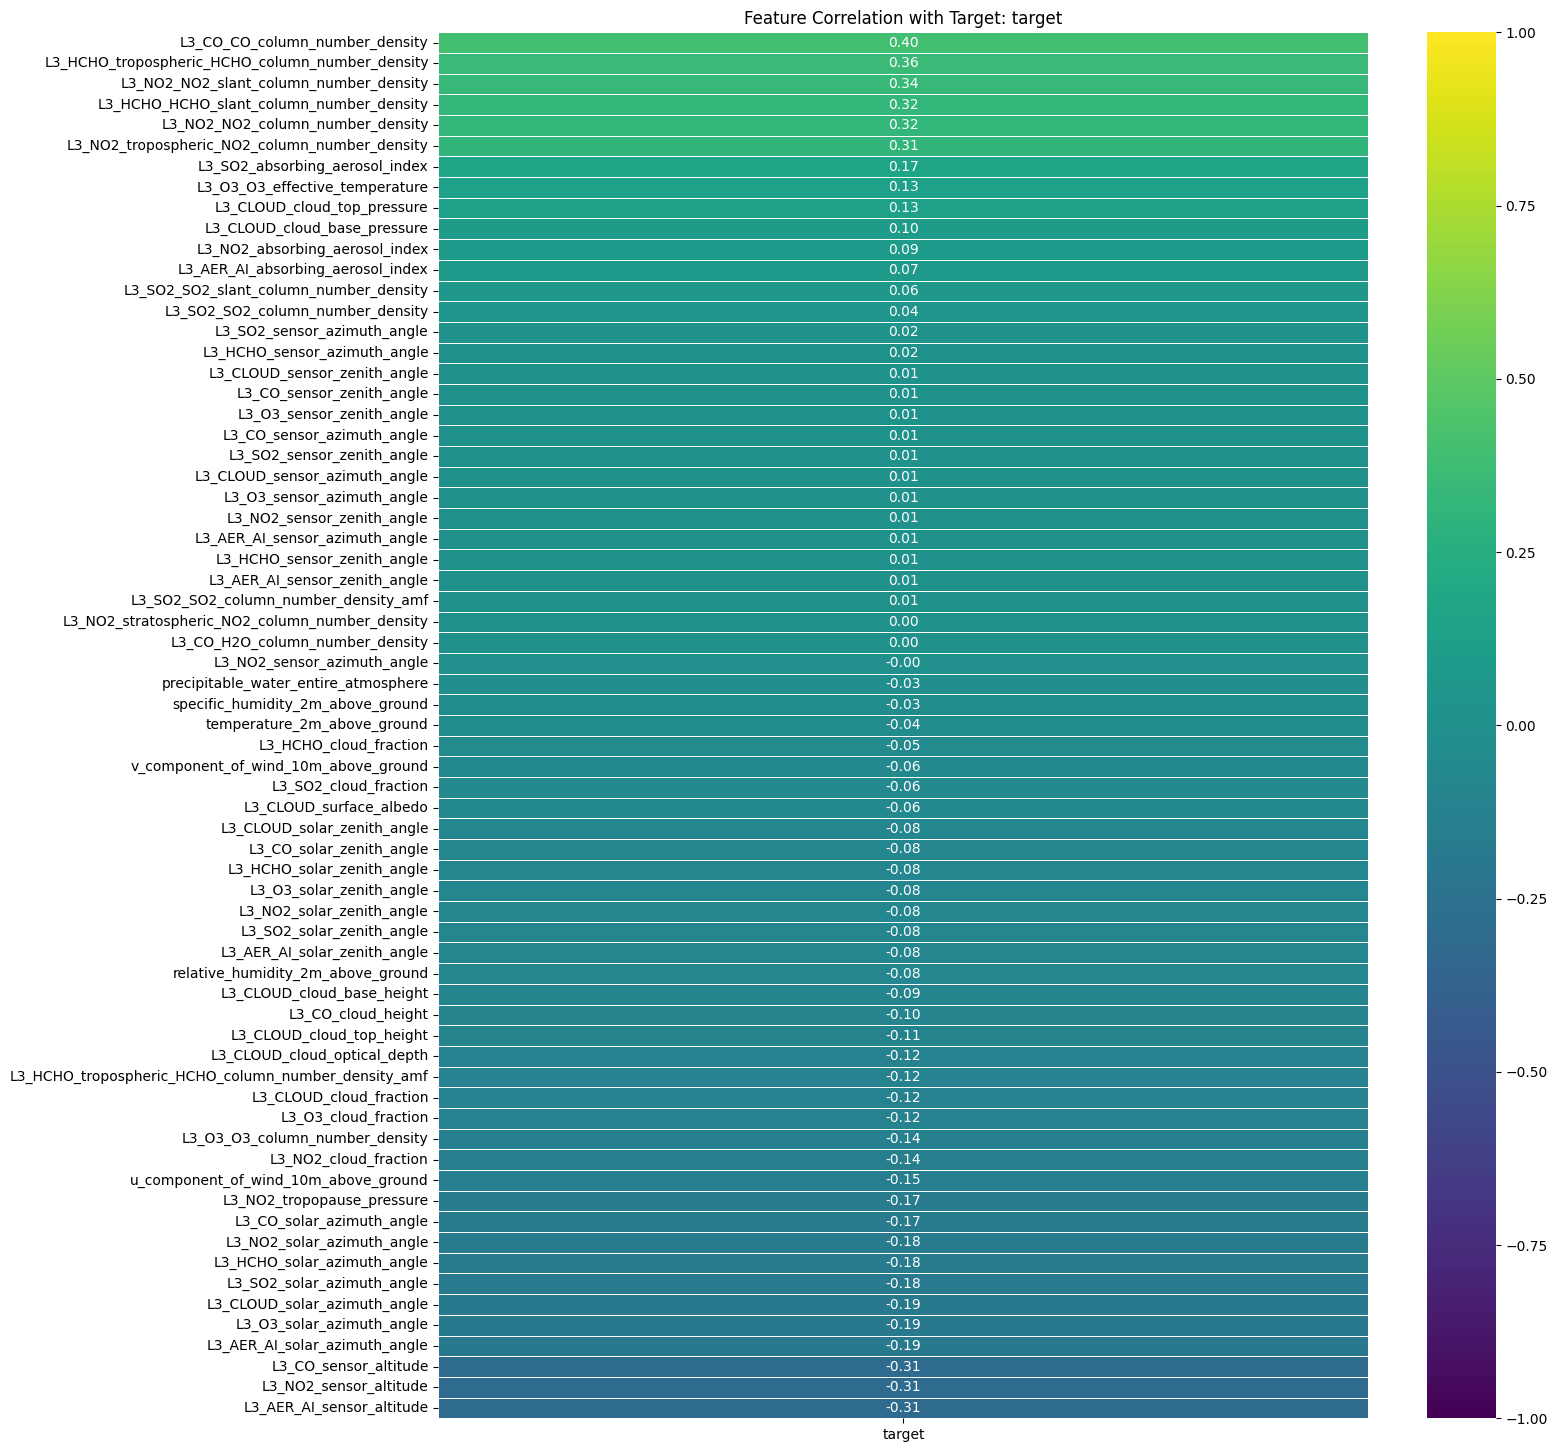

In [28]:
def plot_target_correlation(data, target_col, title="Feature Correlation with Target"):
    """Plots a sorted heatmap showing the correlation of all features with the target."""
    correlations = data.corr(numeric_only=True)[[target_col]]
    correlations = correlations.sort_values(by=target_col, ascending=False)
    correlations = correlations.drop(target_col)

    plt.figure(figsize=(15, 18))
    sns.heatmap(correlations, annot=True, cmap='viridis',
                vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"{title}: {target_col}")
    plt.show()

plot_target_correlation(df, "target")

### 5.2 Angle Consolidation - Relative Azimuth & Zenith

Each satellite band independently records solar/sensor azimuth and zenith angles. Since the sun position is the same for all instruments at a given time/location, these columns are **highly collinear**.

**Strategy:** Compute the mean across all bands and then derive:
- `relative_azimuth` = |mean solar azimuth − mean sensor azimuth|
- `relative_zenith` = |mean solar zenith − mean sensor zenith|

All original per-band angle columns are then dropped.

In [29]:
def relative_mean_angles(df: pd.DataFrame):
    angle_map = {
        'solar_azimuth': [col for col in df.columns if 'solar_azimuth_angle' in col],
        'sensor_azimuth': [col for col in df.columns if 'sensor_azimuth_angle' in col],
        'solar_zenith': [col for col in df.columns if 'solar_zenith_angle' in col],
        'sensor_zenith': [col for col in df.columns if 'sensor_zenith_angle' in col]
    }

    mean_var = pd.DataFrame()
    for name, cols in angle_map.items():
        mean_var[f'mean_{name}'] = df[cols].mean(axis=1)

    df['relative_azimuth'] = np.abs(mean_var['mean_solar_azimuth'] - mean_var['mean_sensor_azimuth'])


    df['relative_zenith'] = np.abs(mean_var['mean_solar_zenith'] - mean_var['mean_sensor_zenith'])

    # Calculate Air Mass Factor Proxy (1 / cos(solar_zenith))
    # This is physically significant for light path length through the atmosphere
    #df['solar_zenith_rad'] = np.radians(df['mean_solar_zenith'])
    #df['air_mass_factor_proxy'] = 1 / np.cos(df['solar_zenith_rad'])

    # 5. Clean up: Remove all the original redundant angle columns
    all_original_angles = [col for list_of_cols in angle_map.values() for col in list_of_cols]
    df.drop(columns=all_original_angles, inplace=True)
    #df.drop(columns=all_original_angles + ['solar_zenith_rad'], inplace=True)

    print(f"Reduced features. New columns added: {list(df.columns[-6:])}")
    return df

df = relative_mean_angles(df)

Reduced features. New columns added: ['L3_SO2_SO2_column_number_density_amf', 'L3_SO2_SO2_slant_column_number_density', 'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction', 'relative_azimuth', 'relative_zenith']


Dataset schema after angle consolidation - 44 columns remain (down from 70).

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 44 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

### 5.3 Air Mass Factors (AMF) & Atmospheric Indices

We engineer physically meaningful ratio features:

| Feature | Formula | Physical Meaning |
|---|---|---|
| `AMF_NO2` | slant_NO2 / vertical_NO2 | Light path length through atmosphere for NO₂ |
| `AMF_SO2_calc` | slant_SO2 / vertical_SO2 | Same for SO₂ |
| `AMF_HCHO_calc` | slant_HCHO / tropospheric_HCHO | Air mass factor proxy for formaldehyde |
| `NO2_Tropo_Ratio` | tropospheric_NO2 / total_NO2 | Fraction of NO₂ in troposphere (pollution signal) |
| `Cloud_Thickness_Pressure` | cloud_base_pressure − cloud_top_pressure | Pressure depth of cloud layer |

We also reduce collinearity in repeated measurements:
- **`mean_cloud_fraction`** - average of all per-band cloud fraction columns (then drop originals)
- **`mean_sensor_altitude`** - average of all sensor altitude columns (then drop originals)

In [31]:
def calculate_air_mass_factors(df):
    """
    Calculates the ratio between slant and vertical columns.
    Matches exact column names from your df.info().
    """
    # NO2 AMF
    df['AMF_NO2'] = df['L3_NO2_NO2_slant_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # SO2 AMF (Using the slant and column density)
    df['AMF_SO2_calc'] = df['L3_SO2_SO2_slant_column_number_density'] / df['L3_SO2_SO2_column_number_density']
    
    # HCHO AMF (Using slant and tropospheric column density)
    df['AMF_HCHO_calc'] = df['L3_HCHO_HCHO_slant_column_number_density'] / df['L3_HCHO_tropospheric_HCHO_column_number_density']
    
    return df

def calculate_atmospheric_indices(df):
    """
    Calculates environmental ratios and cloud metrics.
    """
    # NO2 Tropo Ratio: How much of the total NO2 is in the troposphere?
    df['NO2_Tropo_Ratio'] = df['L3_NO2_tropospheric_NO2_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # Cloud pressure thickness (Base - Top)
    df['Cloud_Thickness_Pressure'] = df['L3_CLOUD_cloud_base_pressure'] - df['L3_CLOUD_cloud_top_pressure']
    
    return df

def cloud_fraction_reduction(df: pd.DataFrame):
    """ Preventing feature co linearity by taking the mean of the cloud fraction

    Args:
        df (pd.DataFrame): original dataframe

    Returns:
        _type_: output dataframe with the old columns removed and the mean column added
    """
    cloud_frac_cols = [c for c in df.columns if 'cloud_fraction' in c]
    df['mean_cloud_fraction'] = df[cloud_frac_cols].mean(axis=1)
    df = df.drop(columns=cloud_frac_cols, axis = 1)

    return df
def sensor_altitude_reduction(df: pd.DataFrame):
    """ Preventing feature co linearity by taking the mean of the sensor altitudes

    Args:
        df (pd.DataFrame): original dataframe

    Returns:
        _type_: output dataframe with the old columns removed and the mean column added
    """
    sensor_altitude_cols = [c for c in df.columns if 'sensor_altitude' in c]
    df['mean_sensor_altitude'] = df[sensor_altitude_cols].mean(axis=1)
    df = df.drop(columns=sensor_altitude_cols, axis = 1)

    return df

df = cloud_fraction_reduction(df)
df = sensor_altitude_reduction(df)
# --- How to use them ---
df = calculate_air_mass_factors(df)
df = calculate_atmospheric_indices(df)

Dataset schema after feature engineering - 43 columns (engineered features added, collinear ones removed).

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 43 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

### 5.4 Final Column Drop
Remove remaining non-numeric identifier columns (`Date`, `Place_ID`) and structurally redundant cloud geometry columns (`L3_CLOUD_cloud_base_height`, `L3_CLOUD_cloud_base_pressure`) before modelling.

In [33]:
cols_to_drop_2 = [
    "Date",
    "Place_ID",
    "L3_CLOUD_cloud_base_height",
    "L3_CLOUD_cloud_base_pressure"
]

df = df.drop(columns=cols_to_drop_2)
df

target  precipitable_water_entire_atmosphere   
0   0        38.0                             11.000000  \
    1        39.0                             14.600000   
    2        24.0                             16.400000   
    3        49.0                              6.911948   
    4        21.0                             13.900001   
...           ...                                   ...   
335 30552    22.0                              6.700000   
    30553    53.0                              6.300000   
    30554    85.0                              7.100000   
    30555   103.0                             19.100000   
    30556    89.0                             11.600000   

           relative_humidity_2m_above_ground   
0   0                              60.200001  \
    1                              48.799999   
    2                              33.400002   
    3                              21.300001   
    4                              44.700001   
...                                      ...   
335 30552                          68.300003   
    30553                          77.700005   
    30554                          68.500000   
    30555                          66.300003   
    30556                          68.400002   

           specific_humidity_2m_above_ground  temperature_2m_above_ground   
0   0                                0.00804                    18.516840  \
    1                                0.00839                    22.546533   
    2                                0.00750                    27.031030   
    3                                0.00391                    23.971857   
    4                                0.00535                    16.816309   
...                                      ...                          ...   
335 30552                            0.00352                     4.256799   
    30553                            0.00341                     2.067438   
    30554                            0.00356                     4.438623   
    30555                            0.00523                    10.573236   
    30556                            0.00486                     9.002069   

           u_component_of_wind_10m_above_ground   
0   0                                  1.996377  \
    1                                  3.330430   
    2                                  5.065727   
    3                                  3.004001   
    4                                  2.621787   
...                                         ...   
335 30552                             -4.810586   
    30553                             -2.346421   
    30554                              0.095703   
    30555                              0.434940   
    30556                             -0.710093   

           v_component_of_wind_10m_above_ground   
0   0                                 -1.227395  \
    1                                 -1.188108   
    2                                  3.500559   
    3                                  1.099468   
    4                                  2.670559   
...                                         ...   
335 30552                             -4.195359   
    30553                              0.749136   
    30554                              0.141943   
    30555                             -1.439778   
    30556                              0.887913   

           L3_NO2_NO2_column_number_density   
0   0                              0.000074  \
    1                              0.000076   
    2                              0.000067   
    3                              0.000083   
    4                              0.000070   
...                                     ...   
335 30552                          0.000063   
    30553                          0.000072   
    30554                          0.000068   
    30555                          0.000086   
    30556                          0.000079   

         

---
## 6. 📊 Correlation Analysis (After Feature Engineering)

Re-plot the feature-target correlation heatmap on the final engineered feature set. Compare with the pre-engineering heatmap to assess whether the new features have improved signal quality.

> Features with high positive/negative correlation are strong candidates for the model. Features near zero correlation may contribute noise.

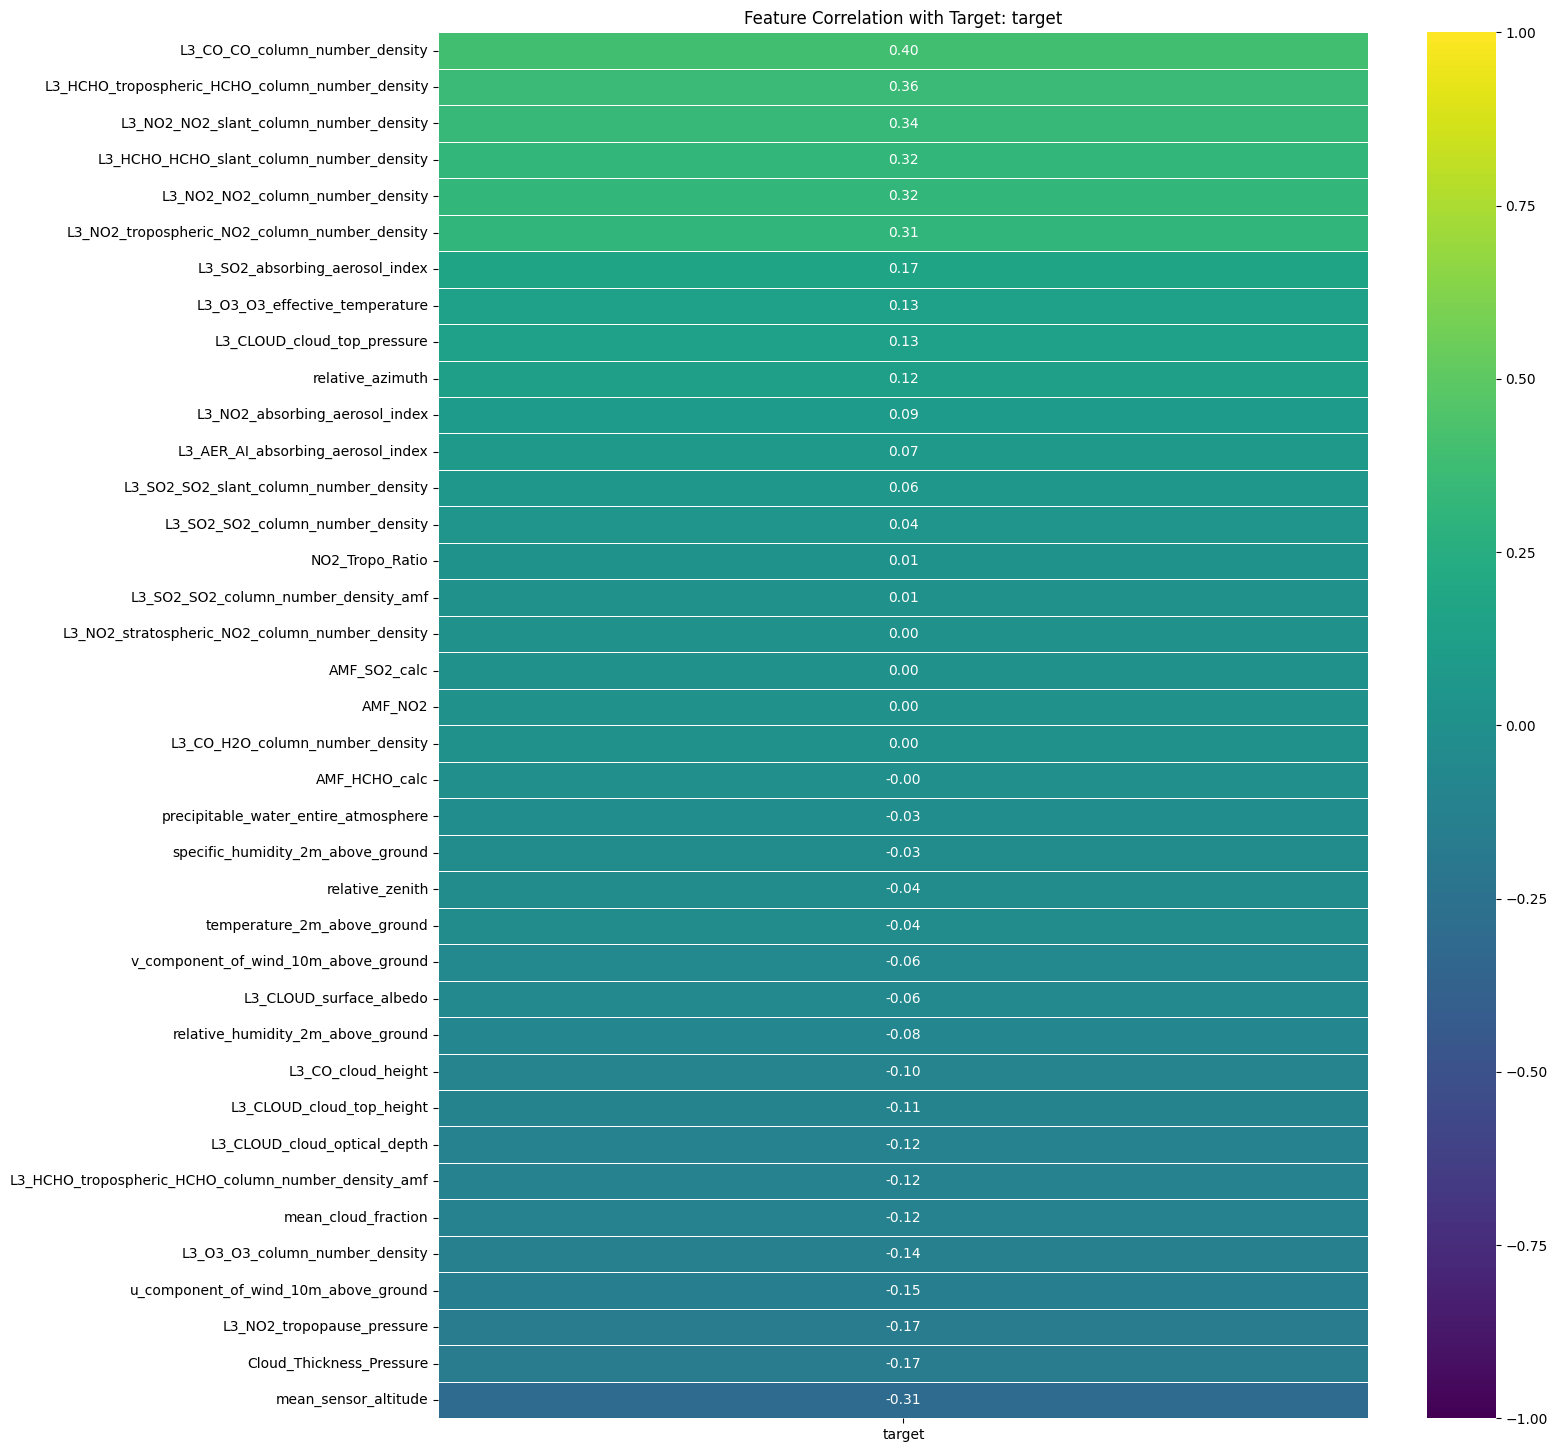

In [34]:
def plot_target_correlation(data, target_col, title="Feature Correlation with Target"):
    """Plots a sorted heatmap showing the correlation of all features with the target."""
    correlations = data.corr(numeric_only=True)[[target_col]]
    correlations = correlations.sort_values(by=target_col, ascending=False)
    correlations = correlations.drop(target_col)

    plt.figure(figsize=(15, 18))
    sns.heatmap(correlations, annot=True, cmap='viridis',
                vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"{title}: {target_col}")
    plt.show()

plot_target_correlation(df, "target")

---
## 7. 📝 EDA Summary

### What We Found
- The dataset covers **~30,500 daily observations** across **340 monitoring stations** over a 94-day window (Jan–Apr 2020)
- Several satellite bands (CH₄, SO₂, HCHO) had **high missingness** - CH₄ was dropped entirely; others were retained after filtering
- Replacing sensor zeros with `NaN` and interpolating within station groups produced a clean, complete feature matrix

### What We Engineered
| Feature | Rationale |
|---|---|
| `relative_azimuth`, `relative_zenith` | Collapsed ~32 redundant per-band angle columns into 2 physically meaningful ones |
| `AMF_NO2`, `AMF_SO2_calc`, `AMF_HCHO_calc` | Air mass factor ratios - encode light path length through atmosphere |
| `NO2_Tropo_Ratio` | Fraction of NO₂ in troposphere - a direct pollution signal |
| `Cloud_Thickness_Pressure` | Pressure depth of cloud layer - affects satellite retrieval quality |
| `mean_cloud_fraction`, `mean_sensor_altitude` | Averaged repeated measurements to reduce multicollinearity |

### Final Dataset
- **Rows:** ~30,500 &nbsp;|&nbsp; **Features:** 39 (down from 82 raw columns)
- All features are numeric and ready for modelling
- The correlation heatmap confirms that NO₂, CO, and meteorological variables carry the strongest signal relative to the target